In [1]:
# Cell 1: Dual Video Generation for Baseline and VLM-PPO
from pathlib import Path
import gymnasium as gym
from stable_baselines3 import PPO
import imageio.v2 as imageio
from IPython.display import Video, display
import torch

log_dir = Path("logs_and_results")
baseline_model_path = log_dir / "baseline_multi_thresh.zip"
vlm_model_path = log_dir / "vlm_multi_thresh.zip"
baseline_video_path = log_dir / "baseline_multi_thresh_demo.mp4"
vlm_video_path = log_dir / "vlm_multi_thresh_demo.mp4"

print("Generating demo videos for both models...")
video_env = gym.make("MountainCar-v0", render_mode="rgb_array")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Baseline Video
print("Loading Baseline model...")
baseline_model = PPO.load(str(baseline_model_path), device=device)
obs, info = video_env.reset()
terminated, truncated = False, False
baseline_frames = []

while not (terminated or truncated):
    baseline_frames.append(video_env.render())
    action, _ = baseline_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = video_env.step(action)

imageio.mimsave(baseline_video_path, baseline_frames, fps=30)
print(f"Saved Baseline video to {baseline_video_path}")

# 2. VLM-PPO Video
print("Loading VLM-PPO model...")
vlm_model = PPO.load(str(vlm_model_path), device=device)
obs, info = video_env.reset()
terminated, truncated = False, False
vlm_frames = []

while not (terminated or truncated):
    vlm_frames.append(video_env.render())
    action, _ = vlm_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = video_env.step(action)

imageio.mimsave(vlm_video_path, vlm_frames, fps=30)
print(f"Saved VLM-PPO video to {vlm_video_path}")

video_env.close()

# 3. Display Videos
print("\n--- Baseline Model Demo ---")
display(Video(str(baseline_video_path), embed=True))

print("\n--- VLM-PPO Model Demo ---")
display(Video(str(vlm_video_path), embed=True))


Generating demo videos for both models...
Loading Baseline model...


d:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\final_project_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved Baseline video to logs_and_results\baseline_multi_thresh_demo.mp4
Loading VLM-PPO model...


d:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\final_project_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved VLM-PPO video to logs_and_results\vlm_multi_thresh_demo.mp4

--- Baseline Model Demo ---



--- VLM-PPO Model Demo ---


,Threshold,Baseline_Steps,VLM_Steps,Speedup
0,-195,364787,55374,6.587695
1,-190,364787,55374,6.587695
2,-180,600000,55374,10.835410
3,-170,600000,55510,10.808863
4,-160,600000,55510,10.808863


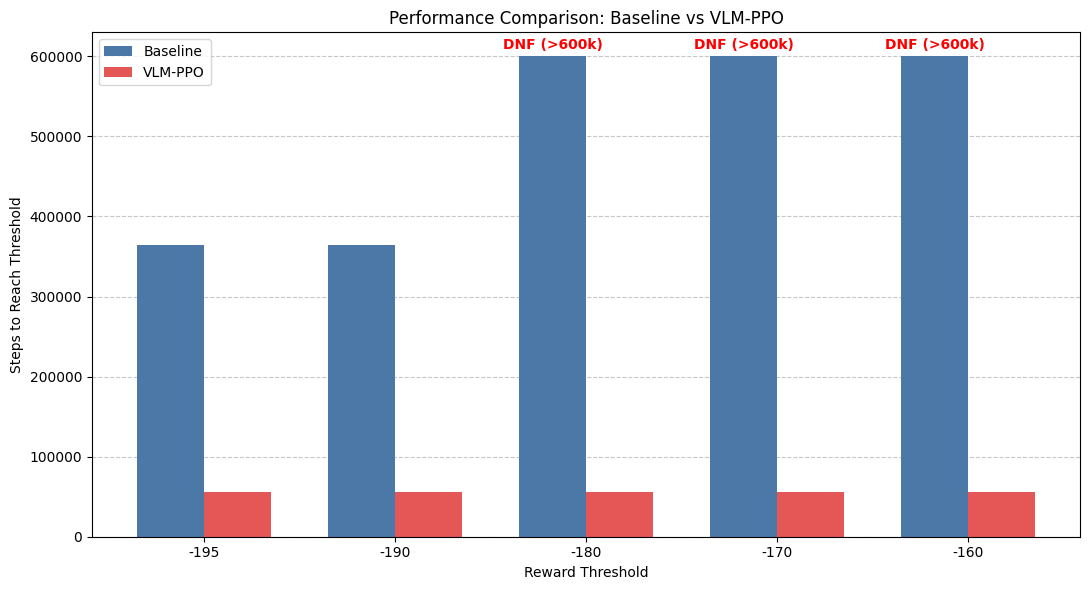

In [2]:
# Cell 2: JSON-based Comparison Chart
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = [-195, -190, -180, -170, -160]
baseline_dnf_cap = 600000
vlm_dnf_cap = 150000

log_dir = Path("logs_and_results")
baseline_json = log_dir / "baseline_thresholds.json"
vlm_json = log_dir / "vlm_thresholds.json"

if not baseline_json.exists() or not vlm_json.exists():
    raise FileNotFoundError(
        f"Missing JSON files. Expected {baseline_json} and {vlm_json}."
    )

with open(baseline_json, "r", encoding="utf-8") as f:
    baseline_data = json.load(f)
with open(vlm_json, "r", encoding="utf-8") as f:
    vlm_data = json.load(f)

# Combine missing/null defaults
rows = []
for t in thresholds:
    key = str(t)
    baseline_steps = baseline_data.get(key)
    if baseline_steps is None:
        baseline_steps = baseline_dnf_cap
    else:
        baseline_steps = int(baseline_steps)
        
    vlm_steps = vlm_data.get(key)
    if vlm_steps is None:
        vlm_steps = vlm_dnf_cap
    else:
        vlm_steps = int(vlm_steps)

    speedup = baseline_steps / vlm_steps if vlm_steps > 0 else np.nan
    rows.append(
        {
            "Threshold": t,
            "Baseline_Steps": baseline_steps,
            "VLM_Steps": vlm_steps,
            "Speedup": speedup,
        }
    )

comparison_df = pd.DataFrame(rows)
display(comparison_df)

x = np.arange(len(thresholds))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_baseline = ax.bar(
    x - bar_width / 2,
    comparison_df["Baseline_Steps"],
    width=bar_width,
    label="Baseline",
    color="#4C78A8",
)
bars_vlm = ax.bar(
    x + bar_width / 2,
    comparison_df["VLM_Steps"],
    width=bar_width,
    label="VLM-PPO",
    color="#E45756",
)

# Annotate DNF for Baseline
for i, b in enumerate(bars_baseline):
    val = int(comparison_df.loc[i, "Baseline_Steps"])
    if val >= baseline_dnf_cap:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 5000,
            "DNF (>600k)",
            ha="center",
            va="bottom",
            color="red",
            fontsize=10,
            fontweight="bold",
        )

# Annotate DNF for VLM-PPO
for i, b in enumerate(bars_vlm):
    val = int(comparison_df.loc[i, "VLM_Steps"])
    if val >= vlm_dnf_cap:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 5000,
            "DNF (>150k)",
            ha="center",
            va="bottom",
            color="red",
            fontsize=10,
            fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("Reward Threshold")
ax.set_ylabel("Steps to Reach Threshold")
ax.set_title("Performance Comparison: Baseline vs VLM-PPO")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 3: Plot Training Curves
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_curve(csv_path, label, color, window_size=50):
    """
    Read the Monitor CSV file and plot the training curve with moving average.
    """
    if not os.path.exists(csv_path):
        print(f"Warning: File not found: {csv_path}")
        return
        
    # The first line of the SB3 Monitor CSV is a comment/metadata, so skip it
    df = pd.read_csv(csv_path, skiprows=1)
    
    # df['l'] represents episode length, df['r'] represents episode reward
    # Calculate global timesteps by cumulatively summing episode lengths
    df['timesteps'] = df['l'].cumsum()
    
    # Calculate moving average using rolling
    smoothed_rewards = df['r'].rolling(window=window_size, min_periods=1).mean()
    
    # 1. Plot the raw reward with low opacity
    plt.plot(df['timesteps'], df['r'], color=color, alpha=0.2)
    
    # 2. Plot the smoothed curve (darker color, solid line)
    plt.plot(df['timesteps'], smoothed_rewards, color=color, linewidth=2, label=label)

# ==================== Plot Settings ====================
plt.figure(figsize=(10, 6))

# Set the sliding window size (e.g., 50 or 100)
WINDOW_SIZE = 50

# Plot Baseline (Blue)
plot_training_curve(
    csv_path='logs_and_results/baseline_monitor.csv', 
    label='Baseline PPO', 
    color='blue', 
    window_size=WINDOW_SIZE
)

# Plot VLM-PPO (Red)
plot_training_curve(
    csv_path='logs_and_results/vlm_monitor.csv', 
    label='VLM-PPO', 
    color='red', 
    window_size=WINDOW_SIZE
)

# Add chart elements
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Episode Reward', fontsize=12)
plt.title('Training Curves: Reward vs. Timesteps', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()
